In [1]:
!pip install pandas numpy scikit-learn xgboost mlflow joblib streamlit matplotlib seaborn


In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import joblib
import mlflow

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.linear_model import LinearRegression

from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import RandomForestRegressor

from xgboost import XGBClassifier
from xgboost import XGBRegressor

from sklearn.metrics import accuracy_score
from sklearn.metrics import f1_score

from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score

In [7]:
df = pd.read_csv(
    "emi_prediction_dataset.csv",
    low_memory=False
)

In [8]:
df.head()

,age,gender,marital_status,education,monthly_salary,employment_type,years_of_employment,company_type,house_type,monthly_rent,...,existing_loans,current_emi_amount,credit_score,bank_balance,emergency_fund,emi_scenario,requested_amount,requested_tenure,emi_eligibility,max_monthly_emi
0,38,Female,Married,Professional,82600.0,Private,0.9,Mid-size,Rented,20000.0,...,Yes,23700.0,660.0,303200.0,70200.0,Personal Loan EMI,850000.0,15,Not_Eligible,500.0
1,38,Female,Married,Graduate,21500.0,Private,7.0,MNC,Family,0.0,...,Yes,4100.0,714.0,92500.0,26900.0,E-commerce Shopping EMI,128000.0,19,Not_Eligible,700.0
2,38,Male,Married,Professional,86100.0,Private,5.8,Startup,Own,0.0,...,No,0.0,650.0,672100.0,324200.0,Education EMI,306000.0,16,Eligible,27775.0
3,58,Female,Married,High School,66800.0,Private,2.2,Mid-size,Own,0.0,...,No,0.0,685.0,440900.0,178100.0,Vehicle EMI,304000.0,83,Eligible,16170.0
4,48,Female,Married,Professional,57300.0,Private,3.4,Mid-size,Family,0.0,...,No,0.0,770.0,97300.0,28200.0,Home Appliances EMI,252000.0,7,Not_Eligible,500.0


In [9]:
df.shape

(404800, 27)

In [10]:
df.columns

Index(['age', 'gender', 'marital_status', 'education', 'monthly_salary',
       'employment_type', 'years_of_employment', 'company_type', 'house_type',
       'monthly_rent', 'family_size', 'dependents', 'school_fees',
       'college_fees', 'travel_expenses', 'groceries_utilities',
       'other_monthly_expenses', 'existing_loans', 'current_emi_amount',
       'credit_score', 'bank_balance', 'emergency_fund', 'emi_scenario',
       'requested_amount', 'requested_tenure', 'emi_eligibility',
       'max_monthly_emi'],
      dtype='object')

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 404800 entries, 0 to 404799
Data columns (total 27 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   age                     404800 non-null  object 
 1   gender                  404800 non-null  object 
 2   marital_status          404800 non-null  object 
 3   education               402396 non-null  object 
 4   monthly_salary          404800 non-null  object 
 5   employment_type         404800 non-null  object 
 6   years_of_employment     404800 non-null  float64
 7   company_type            404800 non-null  object 
 8   house_type              404800 non-null  object 
 9   monthly_rent            402374 non-null  float64
 10  family_size             404800 non-null  int64  
 11  dependents              404800 non-null  int64  
 12  school_fees             404800 non-null  float64
 13  college_fees            404800 non-null  float64
 14  travel_expenses     

In [12]:
df.isnull().sum()

age                          0
gender                       0
marital_status               0
education                 2404
monthly_salary               0
employment_type              0
years_of_employment          0
company_type                 0
house_type                   0
monthly_rent              2426
family_size                  0
dependents                   0
school_fees                  0
college_fees                 0
travel_expenses              0
groceries_utilities          0
other_monthly_expenses       0
existing_loans               0
current_emi_amount           0
credit_score              2420
bank_balance              2426
emergency_fund            2351
emi_scenario                 0
requested_amount             0
requested_tenure             0
emi_eligibility              0
max_monthly_emi              0
dtype: int64

In [13]:
df.duplicated().sum()

np.int64(0)

In [14]:
df = df.drop_duplicates()

In [15]:
num_cols = df.select_dtypes(include=["int64", "float64"]).columns
cat_cols = df.select_dtypes(include=["object"]).columns

In [16]:
df[num_cols] = df[num_cols].fillna(df[num_cols].median())
df[cat_cols] = df[cat_cols].fillna(df[cat_cols].mode().iloc[0])

In [17]:
df.isnull().sum()

age                       0
gender                    0
marital_status            0
education                 0
monthly_salary            0
employment_type           0
years_of_employment       0
company_type              0
house_type                0
monthly_rent              0
family_size               0
dependents                0
school_fees               0
college_fees              0
travel_expenses           0
groceries_utilities       0
other_monthly_expenses    0
existing_loans            0
current_emi_amount        0
credit_score              0
bank_balance              0
emergency_fund            0
emi_scenario              0
requested_amount          0
requested_tenure          0
emi_eligibility           0
max_monthly_emi           0
dtype: int64

In [18]:
import seaborn as sns
import matplotlib.pyplot as plt

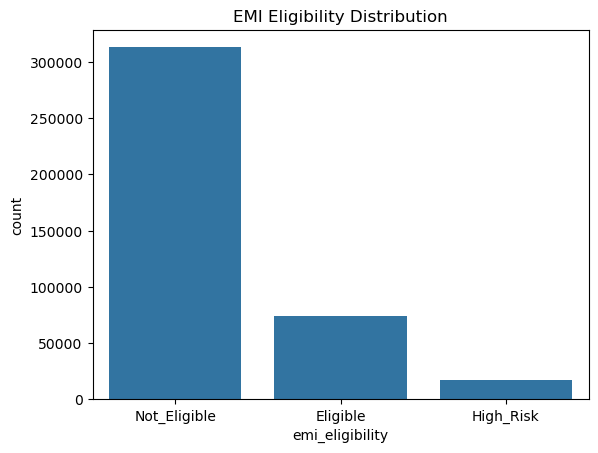

In [19]:
sns.countplot(data=df, x="emi_eligibility")
plt.title("EMI Eligibility Distribution")
plt.show()

In [22]:
numeric_columns = [
    "age",
    "monthly_salary",
    "years_of_employment",
    "monthly_rent",
    "family_size",
    "dependents",
    "school_fees",
    "college_fees",
    "travel_expenses",
    "groceries_utilities",
    "other_monthly_expenses",
    "current_emi_amount",
    "credit_score",
    "bank_balance",
    "emergency_fund",
    "requested_amount",
    "requested_tenure",
    "max_monthly_emi"
]

for col in numeric_columns:
    df[col] = pd.to_numeric(df[col], errors="coerce")

In [23]:
df[numeric_columns] = df[numeric_columns].fillna(
    df[numeric_columns].median()
)

In [24]:
df["total_expenses"] = (
    df["monthly_rent"] +
    df["school_fees"] +
    df["college_fees"] +
    df["travel_expenses"] +
    df["groceries_utilities"] +
    df["other_monthly_expenses"] +
    df["current_emi_amount"]
)

In [25]:
df["expense_to_income_ratio"] = df["total_expenses"] / df["monthly_salary"]
df["emi_to_income_ratio"] = df["current_emi_amount"] / df["monthly_salary"]
df["balance_to_income_ratio"] = df["bank_balance"] / df["monthly_salary"]
df["emergency_fund_ratio"] = df["emergency_fund"] / df["monthly_salary"]

In [26]:
df.head()

,age,gender,marital_status,education,monthly_salary,employment_type,years_of_employment,company_type,house_type,monthly_rent,...,emi_scenario,requested_amount,requested_tenure,emi_eligibility,max_monthly_emi,total_expenses,expense_to_income_ratio,emi_to_income_ratio,balance_to_income_ratio,emergency_fund_ratio
0,38.0,Female,Married,Professional,82600.0,Private,0.9,Mid-size,Rented,20000.0,...,Personal Loan EMI,850000.0,15,Not_Eligible,500.0,83600.0,1.012107,0.286925,3.670702,0.849879
1,38.0,Female,Married,Graduate,21500.0,Private,7.0,MNC,Family,0.0,...,E-commerce Shopping EMI,128000.0,19,Not_Eligible,700.0,19500.0,0.906977,0.190698,4.302326,1.251163
2,38.0,Male,Married,Professional,86100.0,Private,5.8,Startup,Own,0.0,...,Education EMI,306000.0,16,Eligible,27775.0,35600.0,0.413473,0.000000,7.806039,3.765389
3,58.0,Female,Married,High School,66800.0,Private,2.2,Mid-size,Own,0.0,...,Vehicle EMI,304000.0,83,Eligible,16170.0,37400.0,0.559880,0.000000,6.600299,2.666168
4,48.0,Female,Married,Professional,57300.0,Private,3.4,Mid-size,Family,0.0,...,Home Appliances EMI,252000.0,7,Not_Eligible,500.0,58600.0,1.022688,0.000000,1.698080,0.492147


In [27]:
X = df.drop(["emi_eligibility", "max_monthly_emi"], axis=1)

y_class = df["emi_eligibility"]
y_reg = df["max_monthly_emi"]

In [28]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()
y_class_encoded = label_encoder.fit_transform(y_class)

label_encoder.classes_

array(['Eligible', 'High_Risk', 'Not_Eligible'], dtype=object)

In [29]:
categorical_features = X.select_dtypes(include=["object"]).columns
numerical_features = X.select_dtypes(include=["int64", "float64"]).columns

In [30]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

In [31]:
from sklearn.model_selection import train_test_split

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X, y_class_encoded, test_size=0.2, random_state=42
)

X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X, y_reg, test_size=0.2, random_state=42
)

In [32]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.metrics import accuracy_score, f1_score

In [33]:
classification_models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest Classifier": RandomForestClassifier(n_estimators=50, random_state=42),
    "XGBoost Classifier": XGBClassifier(eval_metric="mlogloss", random_state=42)
}

In [34]:
best_class_model = None
best_class_score = 0

for name, model in classification_models.items():
    
    pipe = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])
    
    pipe.fit(X_train_c, y_train_c)
    
    preds = pipe.predict(X_test_c)
    
    acc = accuracy_score(y_test_c, preds)
    f1 = f1_score(y_test_c, preds, average="weighted")
    
    print(name)
    print("Accuracy:", acc)
    print("F1 Score:", f1)
    print("-" * 40)
    
    if acc > best_class_score:
        best_class_score = acc
        best_class_model = pipe

Logistic Regression
Accuracy: 0.8915884387351779
F1 Score: 0.8724957484435262
----------------------------------------
Random Forest Classifier
Accuracy: 0.9321763833992095
F1 Score: 0.9128335452934785
----------------------------------------
XGBoost Classifier
Accuracy: 0.9642168972332016
F1 Score: 0.9570120350523125
----------------------------------------


In [35]:
print("Best Classification Accuracy:", best_class_score)

Best Classification Accuracy: 0.9642168972332016


In [47]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

In [46]:
regression_models = {
    "Linear Regression": LinearRegression(),
    "Random Forest Regressor": RandomForestRegressor(n_estimators=50, random_state=42),
    "XGBoost Regressor": XGBRegressor(random_state=42)
}

In [45]:
best_reg_model = None
best_reg_score = -999

for name, model in regression_models.items():
    
    pipe = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])
    
    pipe.fit(X_train_r, y_train_r)
    
    preds = pipe.predict(X_test_r)
    
    rmse = np.sqrt(mean_squared_error(y_test_r, preds))
    mae = mean_absolute_error(y_test_r, preds)
    r2 = r2_score(y_test_r, preds)
    
    print(name)
    print("RMSE:", rmse)
    print("MAE:", mae)
    print("R2 Score:", r2)
    print("-" * 40)
    
    if r2 > best_reg_score:
        best_reg_score = r2
        best_reg_model = pipe

Linear Regression
RMSE: 4097.789017256386
MAE: 2938.847168896311
R2 Score: 0.7155676193118421
----------------------------------------
Random Forest Regressor
RMSE: 1002.5253755518722
MAE: 355.2334990859684
R2 Score: 0.9829756477631251
----------------------------------------
XGBoost Regressor
RMSE: 785.5818685659585
MAE: 364.33452834184976
R2 Score: 0.9895464752793673
----------------------------------------


In [48]:
print("Best Regression R2 Score:", best_reg_score)

Best Regression R2 Score: 0.9895464752793673


In [49]:
import joblib
import os

os.makedirs("models", exist_ok=True)

joblib.dump(
    best_class_model,
    "models/best_classification_model.pkl"
)

joblib.dump(
    best_reg_model,
    "models/best_regression_model.pkl"
)

joblib.dump(
    label_encoder,
    "models/label_encoder.pkl"
)

joblib.dump(
    X.columns.tolist(),
    "models/input_columns.pkl"
)

print("Models saved successfully")

Models saved successfully
